<a href="https://colab.research.google.com/github/AmandaElisa/gems-finder-tic-ia2/blob/main/notebook/Grupo_9_Sound_Hunters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Baixa o arquivo diretamente para o ambiente do Colab ao rodar a célula

!wget https://raw.githubusercontent.com/samarawwleticia/estudo_python/main/dataset.csv -O dataset.csv

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv('dataset.csv')

df.info()

--2026-09-03 02:39:02--  https://raw.githubusercontent.com/samarawwleticia/estudo_python/main/dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20118244 (19M) [text/plain]
Saving to: ‘dataset.csv’

dataset.csv         100%[===================>]  19.19M  --.-KB/s    in 0.1s    

2026-09-03 02:39:02 (150 MB/s) - ‘dataset.csv’ saved [20118244/20118244]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   t

Primeiramente, vou remover a coluna Unnamed: 0 pois é uma coluna desnecessária.  

In [ ]:
df = df.drop(columns=['Unnamed: 0'])

Agora, vamos remover as linhas duplicadas do dataframes.



In [ ]:
df.drop_duplicates(keep='first', inplace=True)

Iriamos identificar e tratar os outliers mas percebemos que nesse caso não seria necessário devido aos 114 diferentes gêneros musicais que possuem características muito distintas entre si e portanto alertariam muitos outliers como em instrumentalness.


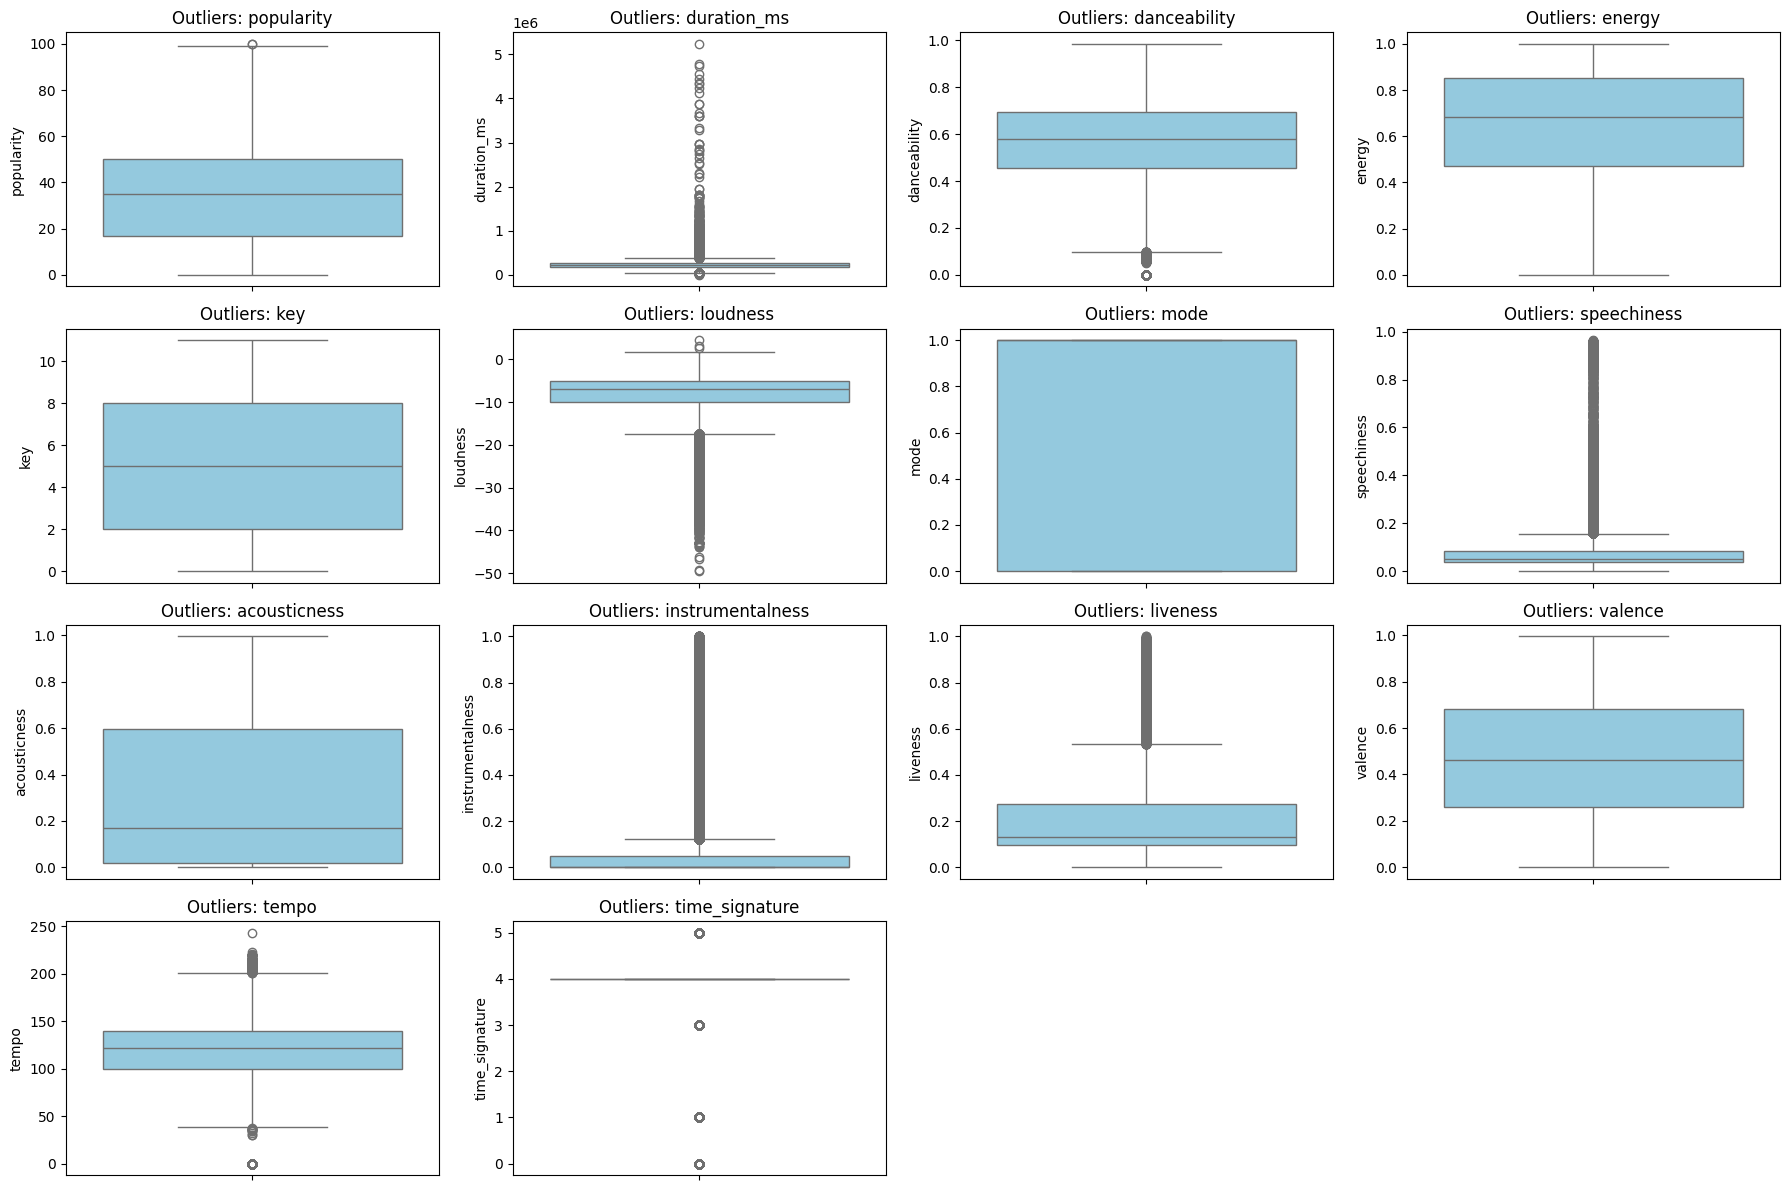

In [ ]:
# Selecionando apenas as colunas numéricas (excluindo booleanas e objetos)
colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

# Configurando a área de plotagem
plt.figure(figsize=(18, 12))

# Criando boxplots para todas as colunas numéricas para visualização rápida
for i, col in enumerate(colunas_numericas, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers: {col}')
    plt.tight_layout()

plt.show()

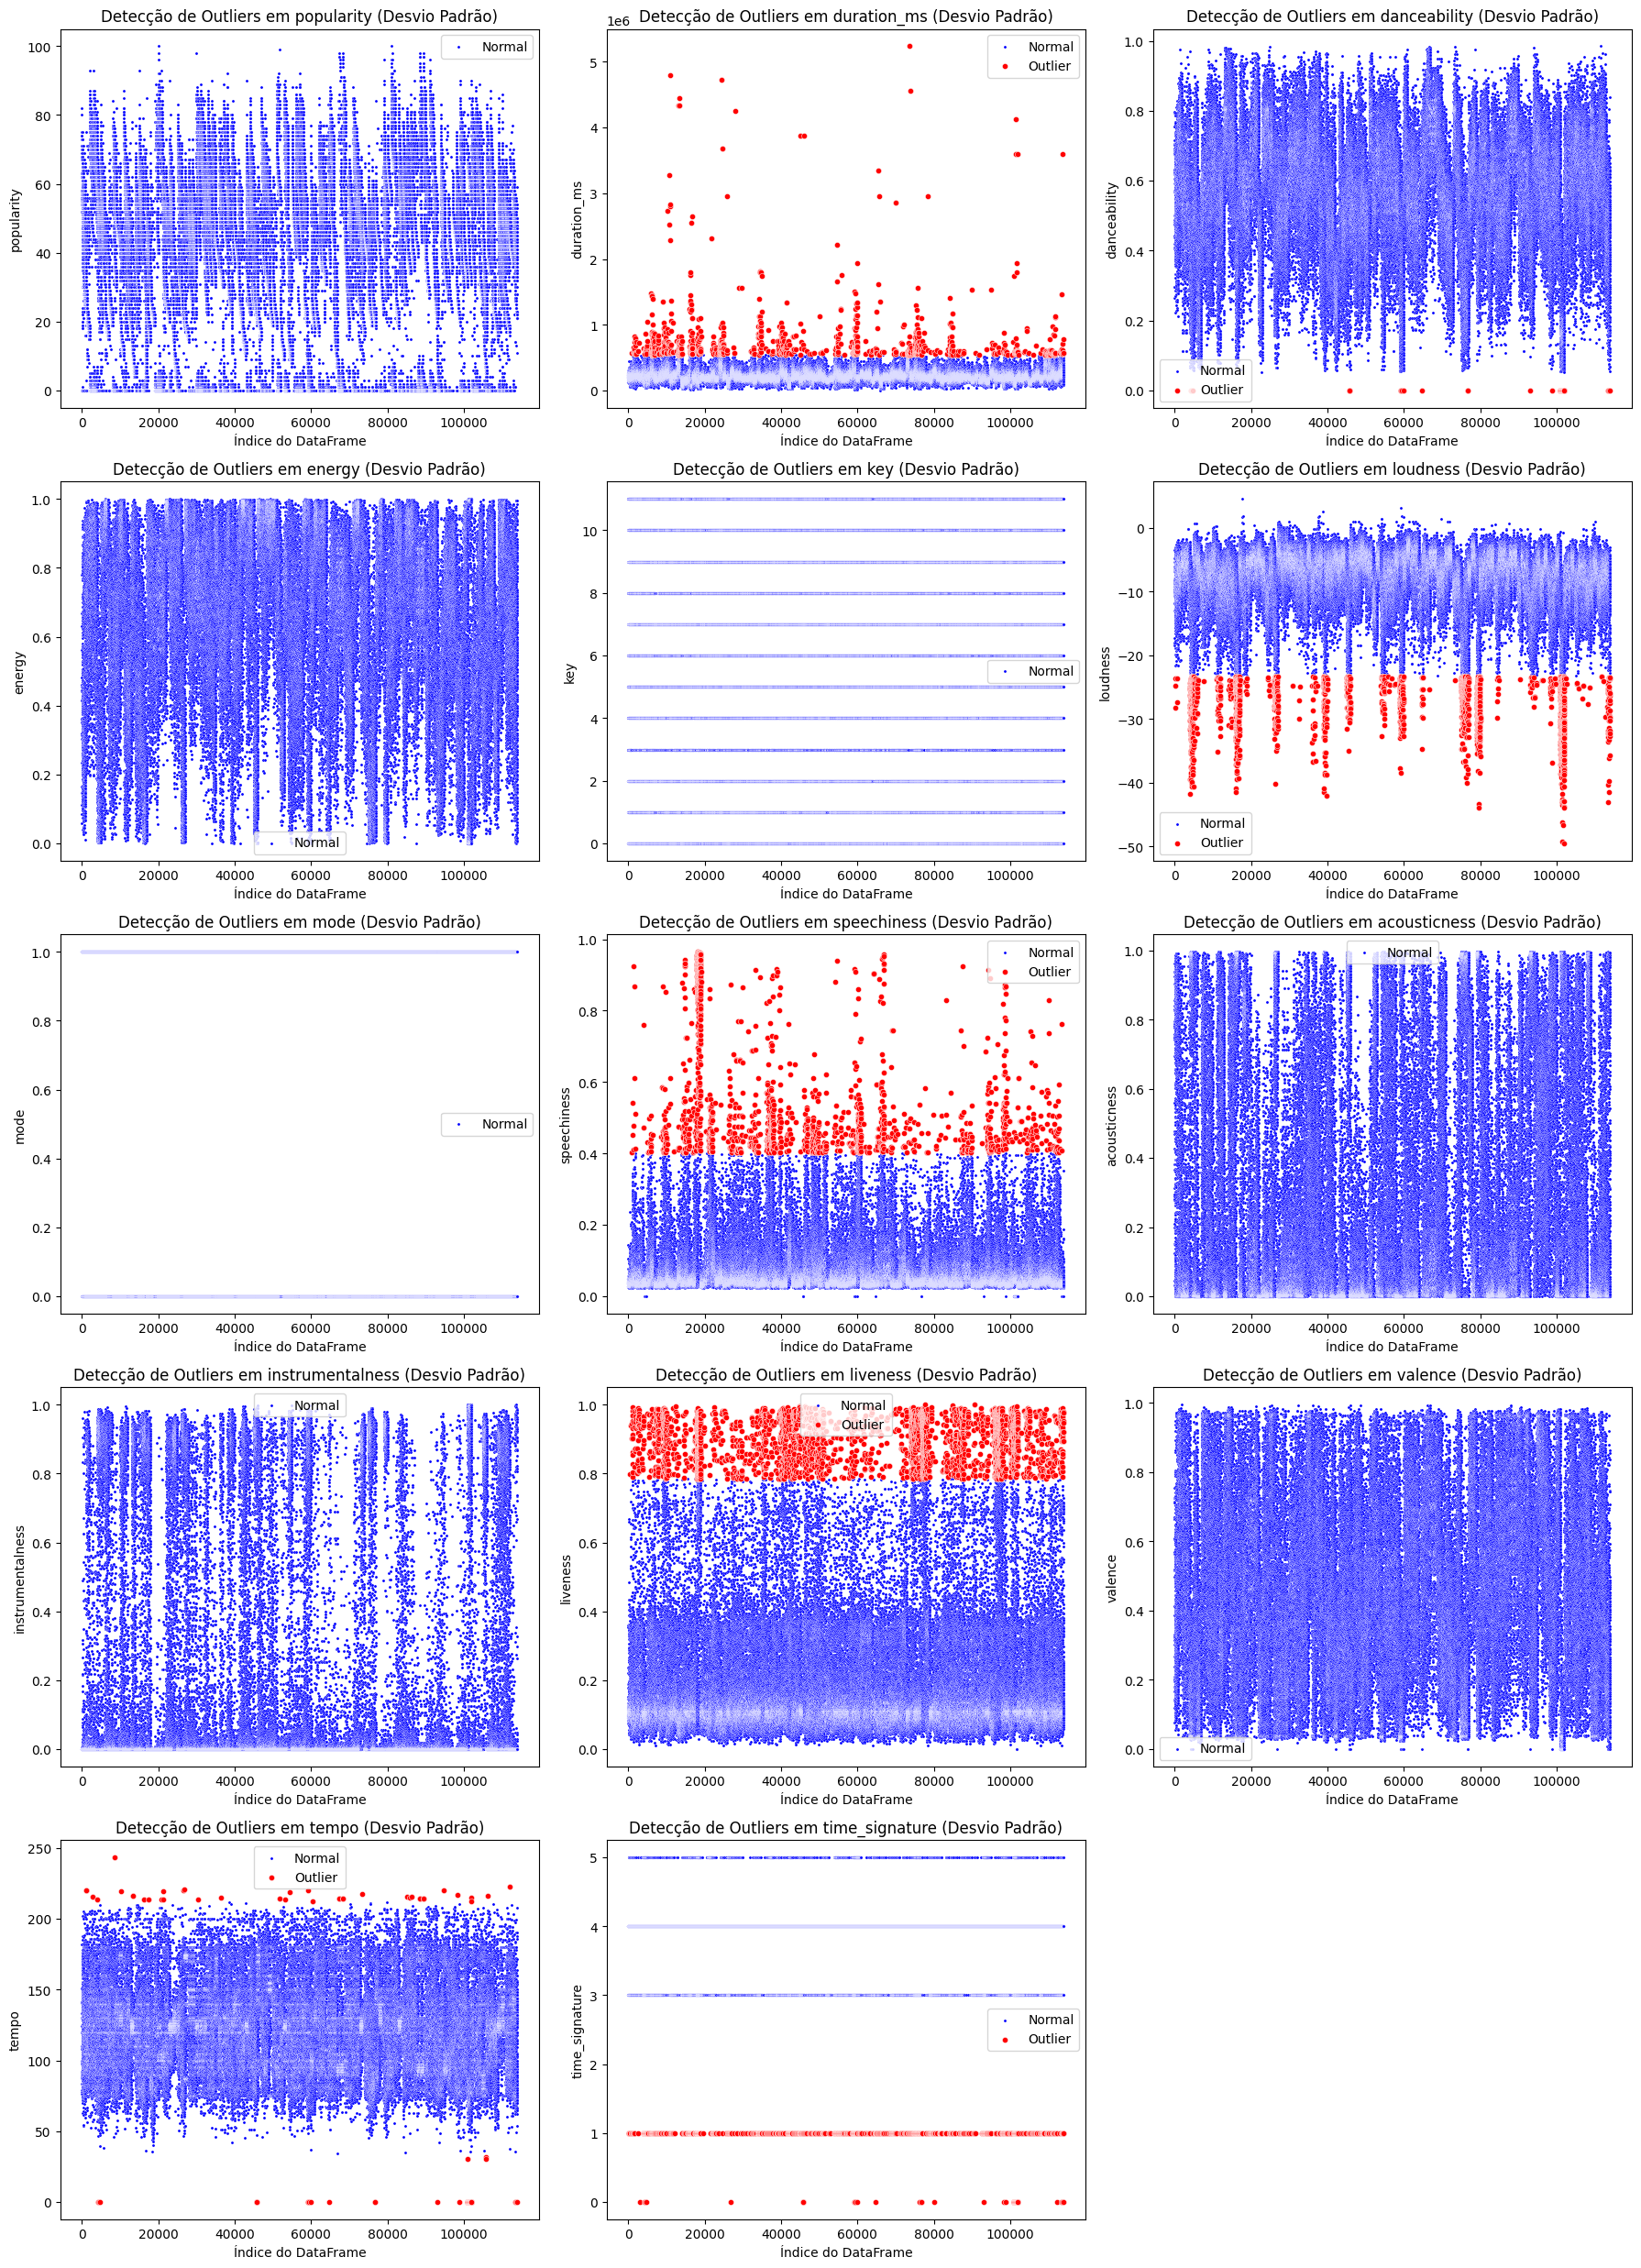

In [ ]:
# Seleciona apenas as colunas numéricas do DataFrame
numerical_cols = df.select_dtypes(include=['number']).columns

# Define o número de colunas para os subplots
num_cols = 3 # Você pode ajustar este valor conforme necessário
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols

# Cria a figura e os subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 6, num_rows * 5))
axes = axes.flatten() # Achata o array de eixos para facilitar a iteração

for i, col in enumerate(numerical_cols):
    mean_val = df[col].mean()
    std_val = df[col].std()

    # Define os limites para outliers (por exemplo, 3 desvios padrão)
    lower_bound = mean_val - (3 * std_val)
    upper_bound = mean_val + (3 * std_val)

    # Identifica os outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Cria um gráfico de dispersão para visualizar os dados e os outliers
    sns.scatterplot(x=df.index, y=df[col], ax=axes[i], label='Normal', color='blue', s=5)
    sns.scatterplot(x=outliers.index, y=outliers[col], ax=axes[i], label='Outlier', color='red', s=20)

    axes[i].set_title(f'Detecção de Outliers em {col} (Desvio Padrão)')
    axes[i].set_xlabel('Índice do DataFrame')
    axes[i].set_ylabel(col)
    axes[i].legend()

# Remove subplots vazios, se houver
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Vamos procurar dados nulos no dataset.

In [ ]:
df.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


Identificando a célula em que os valores nulos estão.

In [ ]:
nulos = df[df["artists"].isnull()]
nulos

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [ ]:
# Removendo a linha com valor nulo

track_id_to_exclude = '1kR4gIb7nGxHPI3D2ifs59'
df = df[df['track_id'] != track_id_to_exclude]
print(f"Linha com track_id '{track_id_to_exclude}' removida. Novo tamanho do DataFrame: {df.shape}")

Linha com track_id '1kR4gIb7nGxHPI3D2ifs59' removida. Novo tamanho do DataFrame: (113549, 20)


Dados estão limpos e prontos!

=== Estatística descritiva de popularity ===
count    113549.000000
mean         33.324433
std          22.283855
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


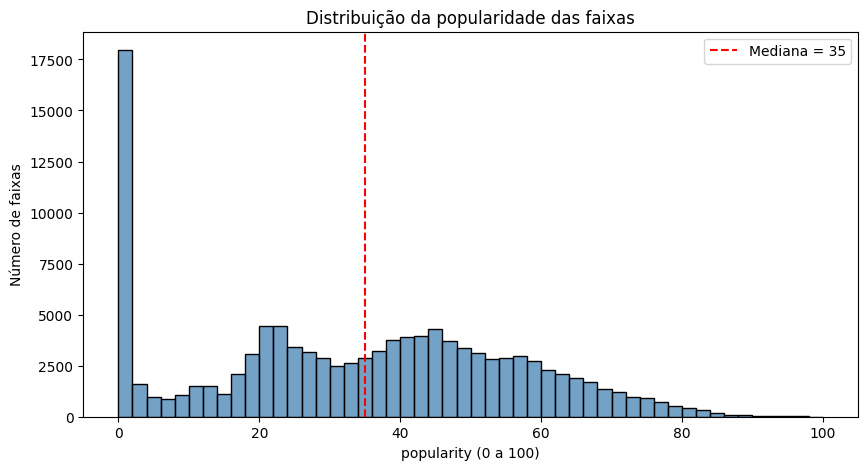


Faixas com popularity == 0: 15843 (14.0%)
Faixas com popularity <= 2: 18984 (16.7%)
=== Percentis de popularity ===
Percentil 10: popularity = 0.0
Percentil 15: popularity = 1.0
Percentil 20: popularity = 10.0
Percentil 25: popularity = 17.0
Percentil 30: popularity = 21.0
Percentil 50: popularity = 35.0
Percentil 75: popularity = 50.0
Percentil 90: popularity = 63.0
=== DEFINIÇÃO DE UNDERGROUND ===
Regra: 2 < popularity < 10 (percentil 20)
Faixas classificadas como underground: 3473 (3.1% do catálogo)
=== Contagem de outliers por feature (método IQR) ===
danceability      :    615 outliers ( 0.5%)  [limites: 0.10 a 1.05]
energy            :      0 outliers ( 0.0%)  [limites: -0.10 a 1.43]
valence           :      0 outliers ( 0.0%)  [limites: -0.37 a 1.32]
acousticness      :      0 outliers ( 0.0%)  [limites: -0.85 a 1.46]
speechiness       :  13167 outliers (11.6%)  [limites: -0.04 a 0.16]
instrumentalness  :  25131 outliers (22.1%)  [limites: -0.07 a 0.12]
liveness          :   86

In [ ]:
# ============================================================
# FASE 2 — ESTATÍSTICA DESCRITIVA & LIMITES (ARTHUR)
# Cole estas células no Colab APÓS a limpeza da Fase 1.
# Neste ponto o df já está: sem 'Unnamed: 0', sem duplicatas,
# sem a linha nula de 'artists'.
# ============================================================


# ------------------------------------------------------------
# CÉLULA 1 — Estatística descritiva da popularidade
# (Responde: qual é o formato da distribuição? onde estão as
#  faixas pouco conhecidas?)
# ------------------------------------------------------------
print("=== Estatística descritiva de popularity ===")
print(df['popularity'].describe())

# Histograma da popularidade — a base visual pra justificar o corte
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], bins=50, color='steelblue')
plt.axvline(df['popularity'].median(), color='red', linestyle='--',
            label=f"Mediana = {df['popularity'].median():.0f}")
plt.title('Distribuição da popularidade das faixas')
plt.xlabel('popularity (0 a 100)')
plt.ylabel('Número de faixas')
plt.legend()
plt.show()

# Quantas faixas estão no "fundo do poço"?
print(f"\nFaixas com popularity == 0: {(df['popularity']==0).sum()} "
      f"({(df['popularity']==0).mean()*100:.1f}%)")
print(f"Faixas com popularity <= 2: {(df['popularity']<=2).sum()} "
      f"({(df['popularity']<=2).mean()*100:.1f}%)")


# ------------------------------------------------------------
# CÉLULA 2 — Percentis: onde cortar o "underground"?
# ------------------------------------------------------------
print("=== Percentis de popularity ===")
for p in [10, 15, 20, 25, 30, 50, 75, 90]:
    print(f"Percentil {p:>2}: popularity = {df['popularity'].quantile(p/100):.1f}")

# OBSERVAÇÃO IMPORTANTE (pro relatório):
# Como ~14% das faixas têm popularity = 0, os percentis baixos
# ficam "colados" no zero. Um corte só por percentil incluiria
# muita faixa de popularity 0, que provavelmente é ruído (sem
# streams), e não joia escondida. Por isso usamos um PISO.


# ------------------------------------------------------------
# CÉLULA 3 — Definição matemática do corte UNDERGROUND
# (Entregável principal da Fase 2)
# ------------------------------------------------------------
PISO = 2                                        # remove o fundo do poço (ruído)
TETO = df['popularity'].quantile(0.20)          # percentil 20 = limiar de "pouco conhecida"

underground = df[(df['popularity'] > PISO) & (df['popularity'] < TETO)]

print("=== DEFINIÇÃO DE UNDERGROUND ===")
print(f"Regra: {PISO} < popularity < {TETO:.0f} (percentil 20)")
print(f"Faixas classificadas como underground: {len(underground)} "
      f"({len(underground)/len(df)*100:.1f}% do catálogo)")

# Cria uma coluna booleana no df pra usar nas fases seguintes
df['is_underground'] = (df['popularity'] > PISO) & (df['popularity'] < TETO)


# ------------------------------------------------------------
# CÉLULA 4 — Outliers nas audio features (método IQR)
# (Responde: existem dados anômalos que são ruído?)
# ------------------------------------------------------------
# Features de áudio que o modelo vai usar de fato
features_audio = ['danceability', 'energy', 'valence',
                  'acousticness', 'speechiness', 'instrumentalness',
                  'liveness', 'tempo', 'loudness', 'duration_ms']

print("=== Contagem de outliers por feature (método IQR) ===")
for col in features_audio:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    print(f"{col:18s}: {n_out:6d} outliers "
          f"({n_out/len(df)*100:4.1f}%)  [limites: {lim_inf:.2f} a {lim_sup:.2f}]")

# NOTA pro relatório: a maioria das features de áudio vai de 0 a 1
# por definição (danceability, energy, valence...), então valores
# fora do [0,1] seriam erro real. Já 'tempo', 'loudness' e
# 'duration_ms' têm escalas próprias e outliers ali podem ser
# faixas legítimas (uma música muito longa, muito alta, etc.).
# Nem todo outlier é ruído — decidir caso a caso.


# ------------------------------------------------------------
# CÉLULA 5 — Checagem de sanidade: valores impossíveis
# (features de áudio 0-1 que estejam fora do intervalo = erro)
# ------------------------------------------------------------
features_0_1 = ['danceability', 'energy', 'valence', 'acousticness',
                'speechiness', 'instrumentalness', 'liveness']
print("=== Valores fora do intervalo [0,1] (erros reais) ===")
for col in features_0_1:
    fora = ((df[col] < 0) | (df[col] > 1)).sum()
    print(f"{col:18s}: {fora} valores impossíveis")

# Duração 0 ou tempo 0 também são suspeitos
print(f"\nFaixas com duration_ms == 0: {(df['duration_ms']==0).sum()}")
print(f"Faixas com tempo == 0: {(df['tempo']==0).sum()}")


# ------------------------------------------------------------
# CÉLULA 6 — Metadados de usuário (resposta conceitual)
# ------------------------------------------------------------
print("=== Metadados disponíveis no dataset ===")
print(df.columns.tolist())
# Resposta pro trabalho: o dataset contém APENAS metadados das
# FAIXAS (áudio + popularidade + gênero). NÃO há dados de ouvintes
# (idade, demografia, histórico). Portanto o modelo é content-based
# (baseado no som), não collaborative (baseado em usuários).
# O perfil do usuário será construído pela SELEÇÃO explícita dele
# dentro do catálogo (artistas/músicas que curte).

Normalização

In [ ]:
# ============================================================
# NORMALIZAÇÃO DAS AUDIO FEATURES
# Passo obrigatório antes de clusterizar ou calcular similaridade.
# Cole no Colab após a limpeza (Fase 1) e a definição de outliers.
# ============================================================

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Escolher as features que descrevem o "som" da música.
#    Deixamos de fora: popularity (é o alvo, não o som),
#    key/mode/time_signature (são categóricas disfarçadas de número),
#    duration_ms e liveness (opcionais — incluir se fizer sentido).
# ------------------------------------------------------------
features_som = ['danceability', 'energy', 'valence', 'acousticness',
                'speechiness', 'instrumentalness', 'loudness', 'tempo']

X = df[features_som].copy()

# ------------------------------------------------------------
# 2. Aplicar o StandardScaler: cada feature fica com média 0
#    e desvio-padrão 1, para nenhuma dominar as outras por
#    causa da escala (tempo ia de 0 a 243, loudness de -49 a 4).
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Guardamos numa versão DataFrame para inspecionar se quiser
X_scaled_df = pd.DataFrame(X_scaled, columns=features_som, index=df.index)

# ------------------------------------------------------------
# 3. Conferir que funcionou: médias ~0, desvios ~1
# ------------------------------------------------------------
print("Médias após normalizar (esperado ~0):")
print(X_scaled_df.mean().round(2))
print("\nDesvios após normalizar (esperado ~1):")
print(X_scaled_df.std().round(2))

# IMPORTANTE: guardar o 'scaler' é essencial.
# Quando um usuário selecionar as músicas favoritas dele,
# você vai precisar transformar as features DELAS com o MESMO
# scaler (scaler.transform(...)), senão a comparação fica
# em escalas diferentes. Nunca crie um scaler novo pro usuário.

# A partir daqui, X_scaled é o que entra no K-Means e nos
# cálculos de similaridade.

Médias após normalizar (esperado ~0):
danceability        0.0
energy              0.0
valence            -0.0
acousticness       -0.0
speechiness         0.0
instrumentalness    0.0
loudness           -0.0
tempo              -0.0
dtype: float64

Desvios após normalizar (esperado ~1):
danceability        1.0
energy              1.0
valence             1.0
acousticness        1.0
speechiness         1.0
instrumentalness    1.0
loudness            1.0
tempo               1.0
dtype: float64


K=2: inertia=60389, silhouette=0.290
K=3: inertia=52567, silhouette=0.181
K=4: inertia=47015, silhouette=0.190
K=5: inertia=41907, silhouette=0.199
K=6: inertia=37441, silhouette=0.208
K=7: inertia=34860, silhouette=0.191
K=8: inertia=32869, silhouette=0.195


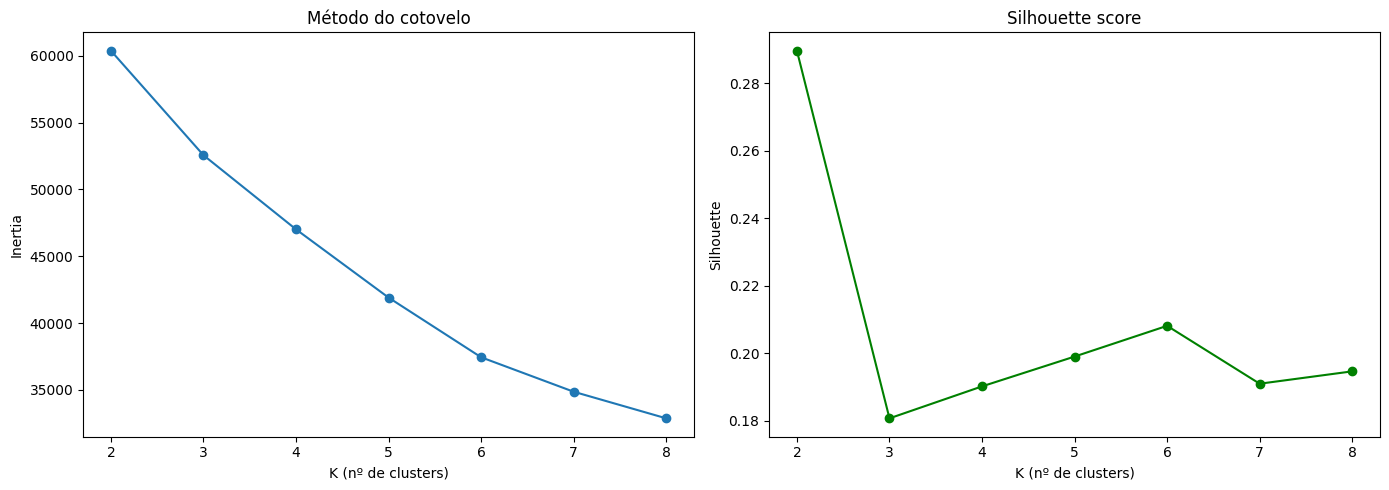

Tamanho de cada cluster:
cluster
0    35074
1    44041
2     8361
3    26073
Name: count, dtype: int64
=== Perfil médio de cada cluster ===
         danceability  energy  valence  acousticness  speechiness  instrumentalness  loudness   tempo
cluster                                                                                              
0                0.48    0.81     0.32          0.06         0.08              0.22     -5.93  136.06
1                0.69    0.73     0.69          0.21         0.11              0.05     -6.44  119.73
2                0.37    0.21     0.19          0.81         0.05              0.79    -20.34  104.41
3                0.54    0.39     0.40          0.66         0.06              0.05    -10.51  113.33

=== Gêneros dominantes por cluster ===
Cluster 0: grindcore, death-metal, black-metal, metalcore, heavy-metal
Cluster 1: reggaeton, reggae, latino, dancehall, forro
Cluster 2: sleep, new-age, ambient, classical, piano
Cluster 3: tango, honky-tonk,

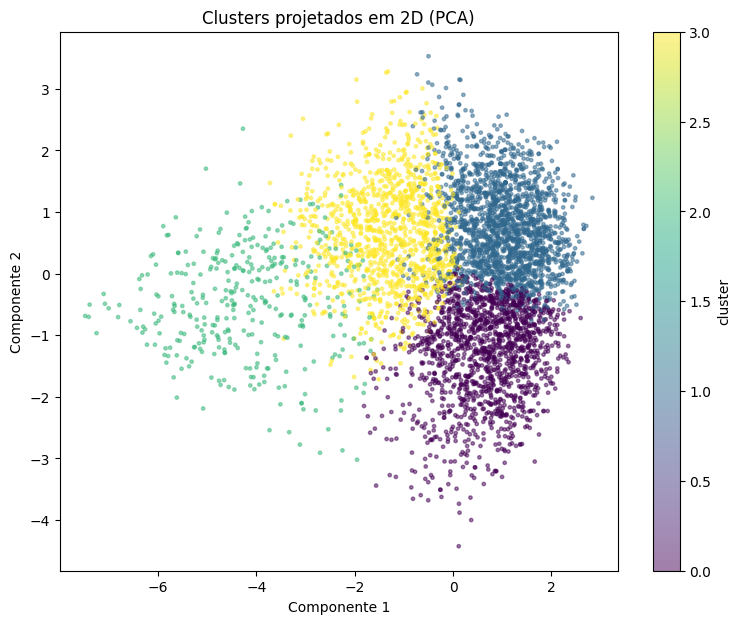

In [ ]:
# ============================================================
# CLUSTERIZAÇÃO — SEGMENTAÇÃO DE MOODS (K-Means)
# Cole no Colab APÓS a normalização (precisa de X_scaled e scaler).
# Objetivo: achar grupos naturais de "som" no catálogo, sem
# rotular à mão. Aprendizado não-supervisionado.
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ------------------------------------------------------------
# CÉLULA 1 — Escolher o número de clusters (K)
# Dois critérios: método do cotovelo (inertia) e silhouette.
# Rodamos numa amostra de 10 mil faixas só para ir rápido.
# ------------------------------------------------------------
np.random.seed(42)
amostra = np.random.choice(len(X_scaled), 10000, replace=False)
X_sample = X_scaled[amostra]

inertias = []
silhouettes = []
Ks = range(2, 9)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels))
    print(f"K={k}: inertia={km.inertia_:.0f}, silhouette={silhouettes[-1]:.3f}")

# Gráficos dos dois critérios lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(Ks), inertias, 'o-')
ax1.set_title('Método do cotovelo')
ax1.set_xlabel('K (nº de clusters)'); ax1.set_ylabel('Inertia')
ax2.plot(list(Ks), silhouettes, 'o-', color='green')
ax2.set_title('Silhouette score')
ax2.set_xlabel('K (nº de clusters)'); ax2.set_ylabel('Silhouette')
plt.tight_layout(); plt.show()

# LEITURA: não há um "joelho" dramático nem um silhouette alto —
# normal em música, onde os moods se sobrepõem. A escolha do K
# é guiada também pelo produto: queremos ~4 moods de uso.


# ------------------------------------------------------------
# CÉLULA 2 — K-Means final com K=4 no dataset inteiro
# ------------------------------------------------------------
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)   # rótulo de cada faixa

print("Tamanho de cada cluster:")
print(df['cluster'].value_counts().sort_index())


# ------------------------------------------------------------
# CÉLULA 3 — Interpretar os clusters (dar nome aos moods)
# Olhamos a média das features ORIGINAIS (não normalizadas)
# porque é o que a gente consegue ler ("energia 0.81 = alta").
# ------------------------------------------------------------
features_som = ['danceability', 'energy', 'valence', 'acousticness',
                'speechiness', 'instrumentalness', 'loudness', 'tempo']

perfil = df.groupby('cluster')[features_som].mean().round(2)
print("=== Perfil médio de cada cluster ===")
print(perfil.to_string())

print("\n=== Gêneros dominantes por cluster ===")
for c in sorted(df['cluster'].unique()):
    top = df[df['cluster'] == c]['track_genre'].value_counts().head(5).index.tolist()
    print(f"Cluster {c}: {', '.join(top)}")

# Depois de ler os perfis, mapeie os nomes à mão:
nomes_mood = {
    0: 'Intenso',       # energia alta, valence baixo, rápido (metal)
    1: 'Festa',         # dançável, valence alto (reggaeton, latino)
    2: 'Relaxamento',   # energia baixa, acústico, instrumental (ambient, sleep)
    3: 'Acústico',      # calmo, acústico, vocal (jazz, tango)
}
df['mood'] = df['cluster'].map(nomes_mood)
print("\nDistribuição de moods:")
print(df['mood'].value_counts())


# ------------------------------------------------------------
# CÉLULA 4 — Visualizar os clusters em 2D (PCA)
# As features são 8-dimensionais (impossível de desenhar).
# O PCA "achata" para 2 dimensões só para visualização.
# ------------------------------------------------------------
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

# Plota uma amostra para não travar o navegador
idx = np.random.choice(len(coords), 5000, replace=False)
plt.figure(figsize=(9, 7))
scatter = plt.scatter(coords[idx, 0], coords[idx, 1],
                      c=df['cluster'].values[idx], cmap='viridis', s=6, alpha=0.5)
plt.title('Clusters projetados em 2D (PCA)')
plt.xlabel('Componente 1'); plt.ylabel('Componente 2')
plt.colorbar(scatter, label='cluster')
plt.show()

# NOTA: o PCA distorce distâncias (perde informação ao achatar de
# 8D para 2D), então serve só para ter uma ideia visual — a
# clusterização real acontece nas 8 dimensões, não nesse desenho.

Matriz de Correlação (HeatMap)

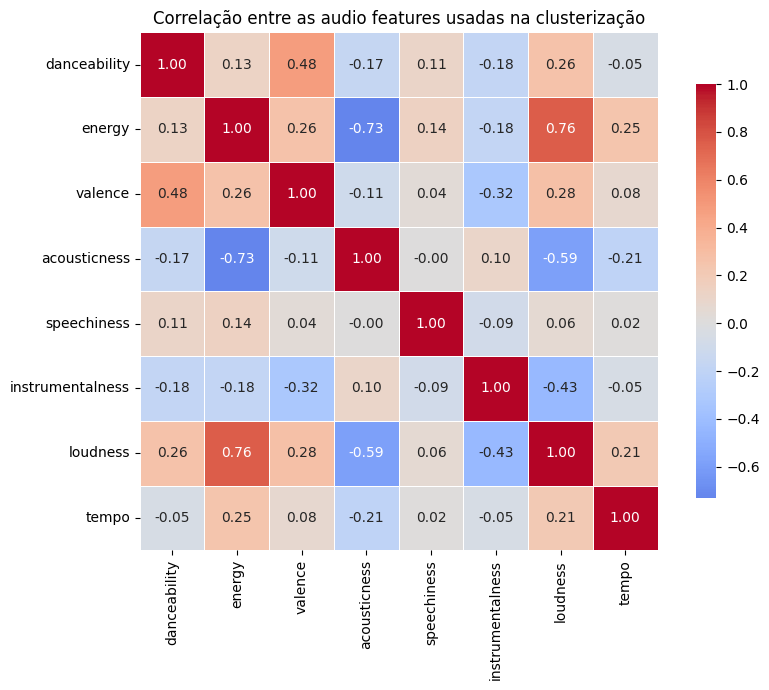

=== Pares mais correlacionados ===
energy            loudness    0.761
acousticness      energy     -0.733
                  loudness   -0.588
danceability      valence     0.477
instrumentalness  loudness   -0.432
                  valence    -0.324
loudness          valence     0.279
energy            valence     0.258
danceability      loudness    0.257
energy            tempo       0.247
dtype: float64


In [ ]:
# ============================================================
# CORRELAÇÃO ENTRE AS AUDIO FEATURES
# Objetivo: checar multicolinearidade antes de confiar na
# clusterização.
# ============================================================

corr = df[features_som].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlação entre as audio features usadas na clusterização')
plt.tight_layout()
plt.show()

# Destaca os pares mais correlacionados (positiva ou negativamente),
# ignorando a diagonal (correlação de uma feature com ela mesma)
corr_pares = corr.where(~np.eye(len(corr), dtype=bool)).unstack().dropna()
corr_pares = corr_pares[corr_pares.index.get_level_values(0) < corr_pares.index.get_level_values(1)]
corr_pares = corr_pares.reindex(corr_pares.abs().sort_values(ascending=False).index)

print("=== Pares mais correlacionados ===")
print(corr_pares.head(10).round(3))

**Correlação entre as audio features**

Pares com correlação mais forte:

- **energy x loudness: 0.76** — músicas mais energéticas tendem a ter mixagem mais alta (esperado)
- **acousticness x energy: -0.73** — faixas acústicas e energéticas ocupam extremos opostos
- **acousticness x loudness: -0.59** — mesma lógica: acústico tende a ser mais "baixo"

**Leitura dos resultados:**

- Demais correlações ficam abaixo de 0.5
- Nenhum par passa de 0.85 → sem multicolinearidade grave

**Conclusão:** mantivemos todas as 8 features na clusterização, com a ressalva de que o par energy/loudness representa uma redundância parcial a considerar em análises futuras.

**Métricas de validação adicionais (sobre o K-Means já treinado)**

In [ ]:
# ============================================================
# MÉTRICAS DE VALIDAÇÃO ADICIONAIS DO CLUSTERING
# Complementa o silhouette já calculado, sem refazer o K-Means.
# ============================================================

from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_score

# Como o dataset é grande, o silhouette em cima de tudo é lento —
# usamos uma amostra, igual já foi feito na escolha do K
np.random.seed(42)
amostra_validacao = np.random.choice(len(X_scaled), 10000, replace=False)

sil = silhouette_score(X_scaled[amostra_validacao], df['cluster'].values[amostra_validacao])
db = davies_bouldin_score(X_scaled, df['cluster'])
ch = calinski_harabasz_score(X_scaled, df['cluster'])

print("=== Métricas de validação do K-Means (K=4) ===")
print(f"Silhouette Score:        {sil:.3f}  (quanto mais perto de 1, melhor)")
print(f"Davies-Bouldin Index:    {db:.3f}  (quanto mais perto de 0, melhor)")
print(f"Calinski-Harabasz Index: {ch:.1f}  (quanto maior, melhor)")

=== Métricas de validação do K-Means (K=4) ===
Silhouette Score:        0.190  (quanto mais perto de 1, melhor)
Davies-Bouldin Index:    1.628  (quanto mais perto de 0, melhor)
Calinski-Harabasz Index: 26159.8  (quanto maior, melhor)


**Validação da clusterização (K=4)**

Métricas complementares ao silhouette score usado na escolha do K:

- **Davies-Bouldin: 1.63** — separação moderada entre clusters (quanto mais perto de 0, melhor)
- **Calinski-Harabasz: 26.159,8** — dispersão entre clusters bem maior que dentro deles (quanto maior, melhor)

**Leitura dos resultados:**

- Davies-Bouldin moderado + silhouette baixo (0.19) → clusters com sobreposição parcial nas fronteiras
- Calinski-Harabasz alto → grupos estatisticamente distintos como um todo

**Conclusão:** resultado esperado para audio features — moods musicais não são categorias estanques, e uma mesma música pode ter características intermediárias entre dois clusters. Consideramos isso uma limitação conhecida da abordagem, não um problema da implementação.


**Tabela mood x popularidade (achar as "joias escondidas" por vibe)**

=== Faixas por mood e popularidade (contagem) ===
faixa_popularidade  Sem streams (ruído)  Underground  Nicho  Médio  Popular  \
mood                                                                          
Acústico                           4308          403   7330  11492     2540   
Festa                              9052         1649  11454  16437     5449   
Intenso                            4197          915  12254  14566     3142   
Relaxamento                        1427          506   3092   3039      297   
Total                             18984         3473  34130  45534    11428   

faixa_popularidade   Total  
mood                        
Acústico             26073  
Festa                44041  
Intenso              35074  
Relaxamento           8361  
Total               113549  

=== % de cada faixa de popularidade dentro de cada mood ===
faixa_popularidade  Sem streams (ruído)  Underground  Nicho  Médio  Popular
mood                                                    

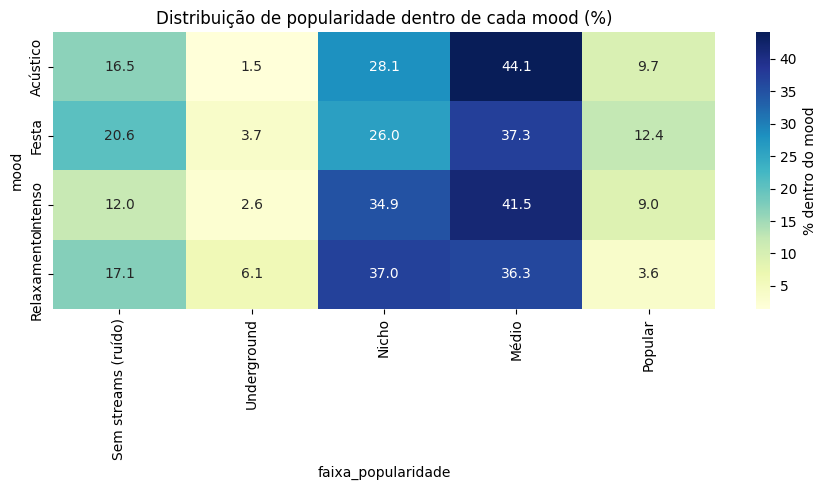

/tmp/ipykernel_5546/1745466624.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mood', y='popularity', palette='Set2')


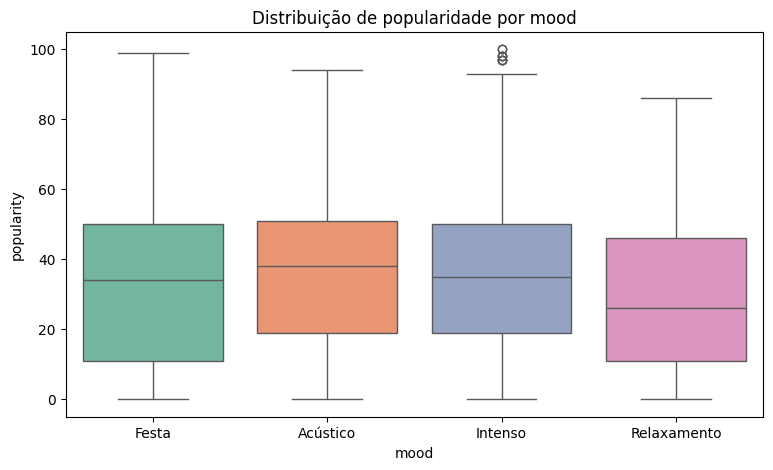

In [ ]:
# ============================================================
# CRUZAMENTO MOOD x FAIXA DE POPULARIDADE
# Objetivo: descobrir quantas faixas "underground" existem
# em cada mood, pra saber se dá pra recomendar descobertas
# em todas as vibes ou só em algumas.
# Usa a mesma lógica de "underground" já definida na Fase 2
# Popularity entre 2 e 10 = underground.
# ============================================================

def classificar_popularidade(p):
    if p <= 2:
        return 'Sem streams (ruído)'
    elif p < 10:
        return 'Underground'
    elif p < 35:
        return 'Nicho'
    elif p < 63:
        return 'Médio'
    else:
        return 'Popular'

df['faixa_popularidade'] = df['popularity'].apply(classificar_popularidade)

# Tabela cruzada: quantas faixas de cada popularidade em cada mood
cruzamento = pd.crosstab(df['mood'], df['faixa_popularidade'], margins=True, margins_name='Total')
ordem_colunas = ['Sem streams (ruído)', 'Underground', 'Nicho', 'Médio', 'Popular', 'Total']
cruzamento = cruzamento[ordem_colunas]
print("=== Faixas por mood e popularidade (contagem) ===")
print(cruzamento)

# Mesma tabela em percentual dentro de cada mood (mais fácil de comparar)
cruzamento_pct = pd.crosstab(df['mood'], df['faixa_popularidade'], normalize='index') * 100
cruzamento_pct = cruzamento_pct[ordem_colunas[:-1]].round(1)
print("\n=== % de cada faixa de popularidade dentro de cada mood ===")
print(cruzamento_pct)

# Heatmap visual
plt.figure(figsize=(9, 5))
sns.heatmap(cruzamento_pct, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '% dentro do mood'})
plt.title('Distribuição de popularidade dentro de cada mood (%)')
plt.tight_layout()
plt.show()

# Boxplot complementar: popularidade por mood
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='mood', y='popularity', palette='Set2')
plt.title('Distribuição de popularidade por mood')
plt.show()

**Cruzamento entre mood e popularidade**

O cruzamento revela diferenças relevantes na proporção de faixas pouco conhecidas dentro de cada mood:

- **Relaxamento** tem a maior % de faixas Underground (6.1%) e a menor % de faixas Populares (3.6%) — é o mood com mais "joias escondidas" disponíveis para descoberta
- **Festa** tem a maior % de faixas Populares (12.4%) — mood mais dominado por músicas já conhecidas
- **Intenso** tem a menor % de faixas "sem streams" (12.0%) — sugere que ouvintes desse mood já buscam mais fora do mainstream por conta própria

**Leitura para o produto:** nem todo mood tem a mesma "reserva" de descobertas. Recomendações de faixas underground serão mais fáceis de entregar em moods como Relaxamento, e mais desafiadoras em moods como Festa, onde a maioria das faixas já é conhecida. Isso é um ponto de atenção para o balanceamento das recomendações entre os quatro moods.